In [14]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, pairwise_distances
from sklearn.preprocessing import StandardScaler
from math import inf
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

RANDOM_STATE = 42

In [15]:

def compute_sse(X, labels, centers):
    """Compute sum of squared distances of samples to their cluster centers.
       X: (n_samples, n_features)
       labels: array of shape (n_samples,) cluster assignment; noise=-1 ignored.
       centers: array (n_clusters, n_features) for non-noise clusters
    """
    sse = 0.0
    unique = [c for c in np.unique(labels) if c != -1]
    for i, c in enumerate(unique):
        members = X[labels == c]
        if len(members) == 0:
            continue
        center = centers[i]
        sse += np.sum((members - center) ** 2)
    return sse

def centers_from_labels(X, labels):
    """Compute centroid of each non-noise cluster in label order (sorted unique excluding -1)."""
    clusters = [c for c in np.unique(labels) if c != -1]
    centers = []
    for c in clusters:
        centers.append(X[labels == c].mean(axis=0))
    if len(centers) == 0:
        return np.empty((0, X.shape[1]))
    return np.vstack(centers)

def safe_silhouette(X, labels):
    """Compute silhouette score only if there are at least 2 clusters with >1 sample each."""
    unique, counts = np.unique(labels, return_counts=True)
    # exclude noise label -1
    mask = unique != -1
    unique = unique[mask]
    counts = counts[mask]
    if len(unique) < 2:
        return np.nan
    if np.any(counts < 2):
        # silhouette_score requires at least 2 samples per cluster; remove clusters <2? simplest: nan
        return np.nan
    return silhouette_score(X, labels)

def plot_clusters_2d(X, labels, title, ax=None, show_centers=None):
    """Scatter plot for 2D X with cluster labels. show_centers: array of centers to plot."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6,5))
    unique = np.unique(labels)
    palette = sns.color_palette("tab10", n_colors=max(10, len(unique)))
    for i, lab in enumerate(unique):
        mask = labels == lab
        if lab == -1:
            ax.scatter(X[mask,0], X[mask,1], c='k', marker='x', label='noise', alpha=0.6, s=30)
        else:
            ax.scatter(X[mask,0], X[mask,1], c=[palette[i%len(palette)]], label=f'cluster {lab}', s=30, alpha=0.7)
    if show_centers is not None and len(show_centers)>0:
        ax.scatter(show_centers[:,0], show_centers[:,1], c='black', marker='o', s=80, edgecolor='white', linewidth=1.2, label='centroids')
    ax.set_title(title)
    ax.legend(loc='best', fontsize='small')
    return ax


In [16]:
#load CSVs from Dataset2 folder
DATA_DIR = r"C:\Users\keert\OneDrive\Desktop\M25 Data Analytics I Assignment-4\Dataset2"   # change if your folder is elsewhere
csv_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.csv")))

if len(csv_files) == 0:
    raise FileNotFoundError(f"No CSV files found in {DATA_DIR}. Put the 4 datasets there or change DATA_DIR.")

print("Found datasets:")
for f in csv_files:
    print(" -", os.path.basename(f))


Found datasets:
 - Compact.csv
 - Skewed.csv
 - Subclusters.csv
 - wellSeperated.csv



Processing dataset: Compact
  KMeans best k=5, silhouette=0.9133, SSE=4.35


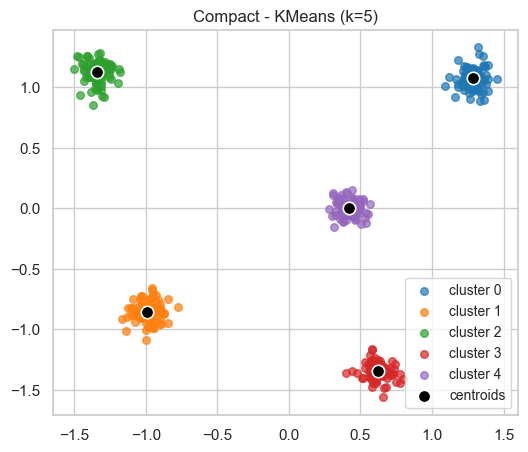

  Agglomerative best k=5, linkage=ward, silhouette=0.9133, SSE=4.35


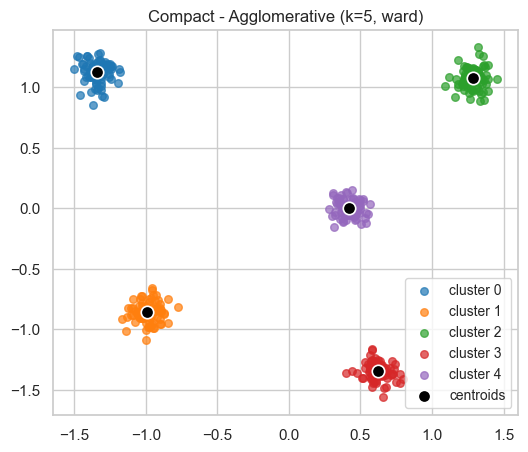

  DBSCAN best eps=0.50, min_samples=3, silhouette=0.9133, noise=0, SSE=4.35


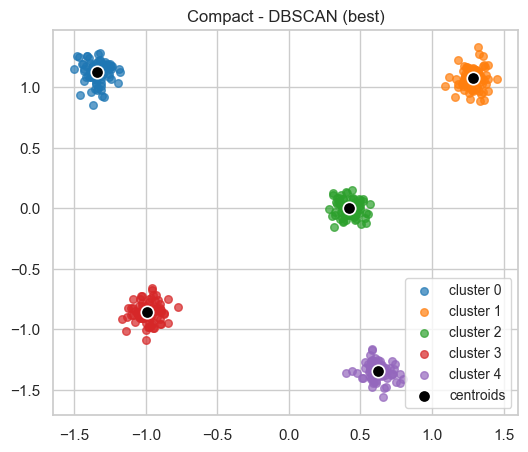


Processing dataset: Skewed
  KMeans best k=3, silhouette=0.4093, SSE=761.86


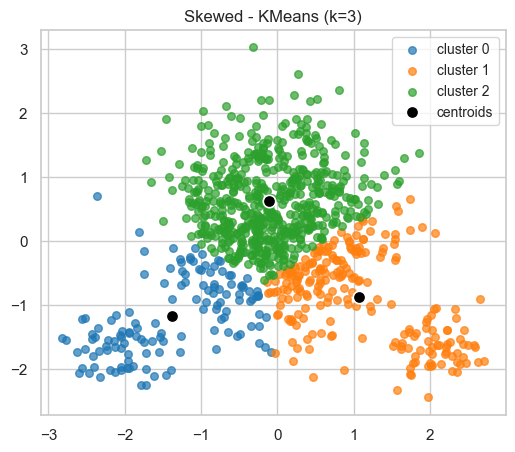

  Agglomerative best k=2, linkage=ward, silhouette=0.4897, SSE=1359.42


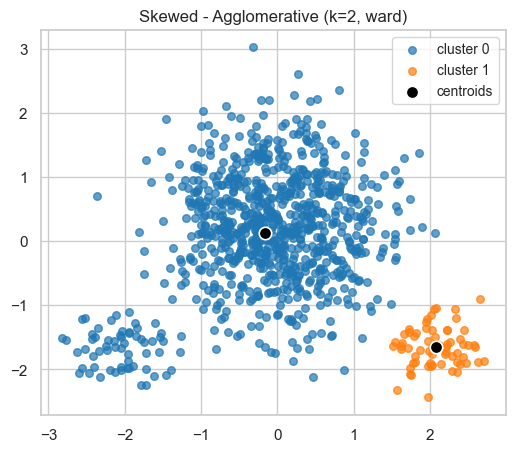

  DBSCAN best eps=0.50, min_samples=30, silhouette=0.4292, noise=21, SSE=821.44


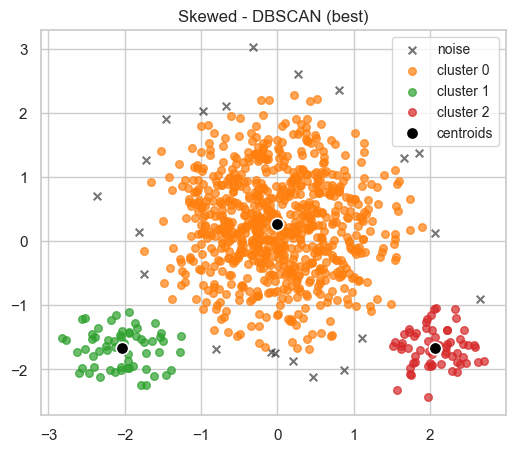


Processing dataset: Subclusters
  KMeans best k=4, silhouette=0.7590, SSE=37.52


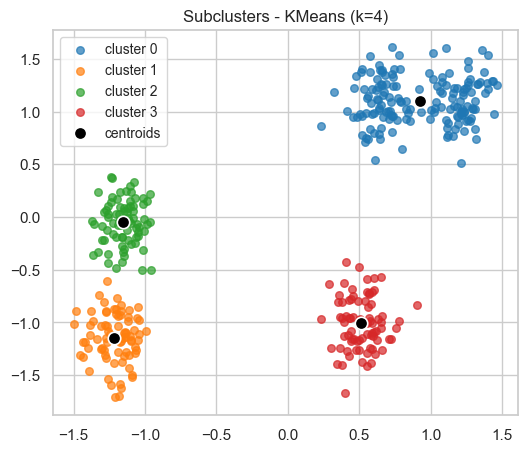

  Agglomerative best k=4, linkage=ward, silhouette=0.7590, SSE=37.52


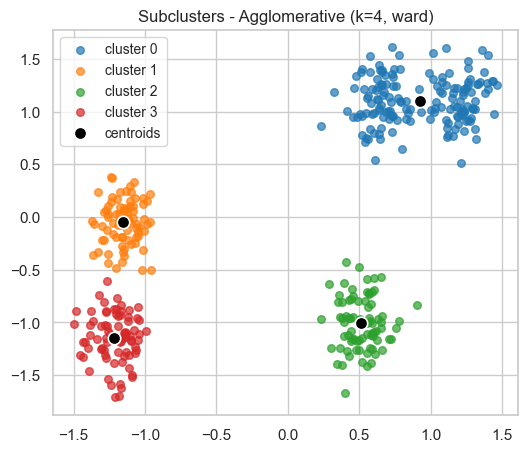

  DBSCAN best eps=0.50, min_samples=3, silhouette=0.7226, noise=0, SSE=85.66


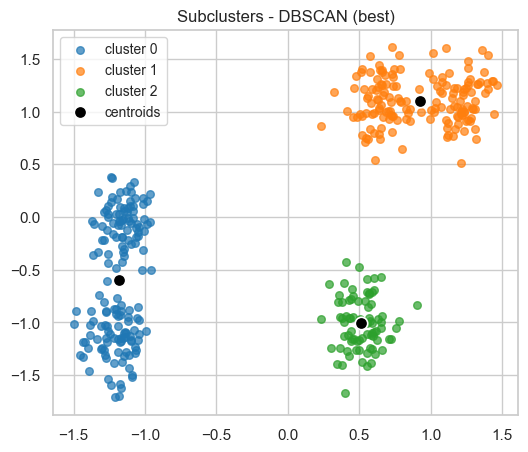


Processing dataset: wellSeperated
  KMeans best k=3, silhouette=0.6137, SSE=118.36


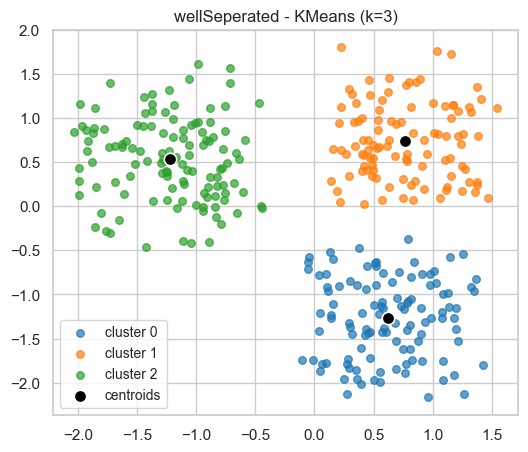

  Agglomerative best k=3, linkage=ward, silhouette=0.6137, SSE=118.36


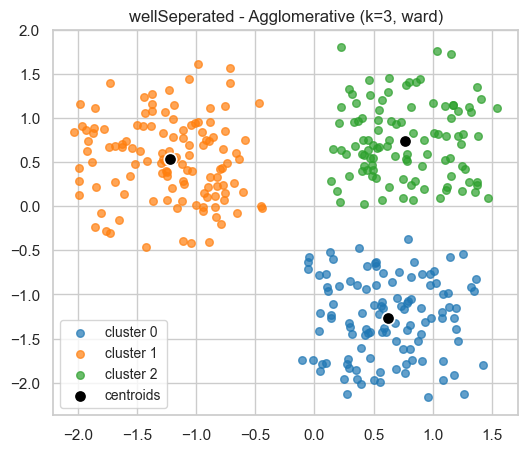

  DBSCAN best eps=0.50, min_samples=30, silhouette=0.5602, noise=15, SSE=102.64


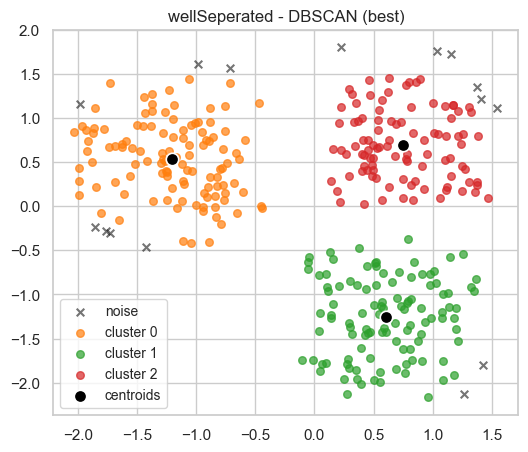

         dataset  kmeans_k  kmeans_silhouette  kmeans_sse  agg_k agg_linkage  \
0        Compact         5           0.913317    4.351241      5        ward   
1         Skewed         3           0.409300  761.862281      2        ward   
2    Subclusters         4           0.758979   37.524700      4        ward   
3  wellSeperated         3           0.613735  118.361148      3        ward   

   agg_silhouette      agg_sse  dbscan_eps  dbscan_min_samples  \
0        0.913317     4.351241         0.5                   3   
1        0.489659  1359.420006         0.5                  30   
2        0.758979    37.524700         0.5                   3   
3        0.613735   118.361148         0.5                  30   

   dbscan_silhouette  dbscan_noise_count  dbscan_sse  
0           0.913317                   0    4.351241  
1           0.429206                  21  821.441100  
2           0.722632                   0   85.655366  
3           0.560201                  15  102.64

In [17]:
#run clustering algorithms and collect results
results_rows = []

# K/Agglomerative search parameters
k_range = list(range(2,10))  # 2..9

# DBSCAN grid
eps_values = np.linspace(0.5, 5.0, 10)  # try range 0.5..5
min_samples_values = [3,5,10,20,30]

OUT_DIR = "task3_plots"
os.makedirs(OUT_DIR, exist_ok=True)

for filepath in csv_files:
    name = os.path.splitext(os.path.basename(filepath))[0]
    print(f"\nProcessing dataset: {name}")
    df = pd.read_csv(filepath, header=None) if 'Unnamed' in pd.read_csv(filepath, nrows=0).columns else pd.read_csv(filepath)
    # Expect two features by assignment. If there are headers, try reading with header=0
    # Ensure X has 2 columns
    if df.shape[1] != 2:
        # try reading with header
        df = pd.read_csv(filepath, header=0)
    X_raw = df.values
    if X_raw.shape[1] != 2:
        raise ValueError(f"Dataset {name} has {X_raw.shape[1]} features, expected 2.")
    # Standardize features (important for distance-based methods)
    scaler = StandardScaler()
    X = scaler.fit_transform(X_raw)

    # ---------- KMeans: choose best k by silhouette ----------
    best_k = None
    best_sil_k = -inf
    best_k_labels = None
    best_k_centers = None
    best_k_sse = None
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = km.fit_predict(X)
        sil = safe_silhouette(X, labels)
        if np.isfinite(sil) and sil > best_sil_k:
            best_sil_k = sil
            best_k = k
            best_k_labels = labels.copy()
            best_k_centers = km.cluster_centers_.copy()
            # compute SSE in original scaled space
            best_k_sse = km.inertia_
    print(f"  KMeans best k={best_k}, silhouette={best_sil_k:.4f}, SSE={best_k_sse:.2f}")

    # plot KMeans
    fig, ax = plt.subplots(figsize=(6,5))
    plot_clusters_2d(X, best_k_labels, f"{name} - KMeans (k={best_k})", ax=ax, show_centers=best_k_centers)
    fig.savefig(os.path.join(OUT_DIR, f"{name}_kmeans_k{best_k}.png"))
    plt.show()
    plt.close(fig)

    # ---------- Agglomerative: choose best k and linkage options ----------
    best_a_k = None
    best_a_sil = -inf
    best_a_labels = None
    best_a_centers = None
    best_a_sse = None
    # try different linkages too
    for linkage in ['ward', 'complete', 'average', 'single']:
        # ward requires euclidean and may fail for non-euclidean but fine here
        for k in k_range:
            try:
                ac = AgglomerativeClustering(n_clusters=k, linkage=linkage)
                labels = ac.fit_predict(X)
            except Exception:
                continue
            sil = safe_silhouette(X, labels)
            if np.isfinite(sil) and sil > best_a_sil:
                best_a_sil = sil
                best_a_k = k
                best_a_labels = labels.copy()
                # compute centers as mean of members in scaled space
                best_a_centers = centers_from_labels(X, labels)
                best_a_sse = compute_sse(X, labels, best_a_centers)
                best_a_linkage = linkage
    print(f"  Agglomerative best k={best_a_k}, linkage={best_a_linkage}, silhouette={best_a_sil:.4f}, SSE={best_a_sse:.2f}")

    # plot Agglomerative
    fig, ax = plt.subplots(figsize=(6,5))
    plot_clusters_2d(X, best_a_labels, f"{name} - Agglomerative (k={best_a_k}, {best_a_linkage})", ax=ax, show_centers=best_a_centers)
    fig.savefig(os.path.join(OUT_DIR, f"{name}_agglomerative_k{best_a_k}_{best_a_linkage}.png"))
    plt.show()
    plt.close(fig)

    # ---------- DBSCAN grid search ----------
    best_db_sil = -inf
    best_db_labels = None
    best_db_params = None
    best_db_centers = None
    best_db_sse = None
    best_db_noise = None

    for eps in eps_values:
        for ms in min_samples_values:
            db = DBSCAN(eps=eps, min_samples=ms)
            labels = db.fit_predict(X)
            # count clusters excluding noise
            unique = np.unique(labels)
            # Need at least 2 non-noise clusters with >=2 samples
            sil = safe_silhouette(X, labels)
            if np.isfinite(sil) and sil > best_db_sil:
                centers = centers_from_labels(X, labels)
                sse = compute_sse(X, labels, centers)
                noise_count = np.sum(labels == -1)
                best_db_sil = sil
                best_db_labels = labels.copy()
                best_db_params = (eps, ms)
                best_db_centers = centers.copy() if centers.size else centers
                best_db_sse = sse
                best_db_noise = int(noise_count)
    if best_db_labels is None:
        print("  DBSCAN: no valid clustering found in grid (or silhouette undefined). We'll record NaNs.")
    else:
        print(f"  DBSCAN best eps={best_db_params[0]:.2f}, min_samples={best_db_params[1]}, silhouette={best_db_sil:.4f}, noise={best_db_noise}, SSE={best_db_sse:.2f}")

    # plot DBSCAN (if none found, try a default sensible one)
    db_labels_to_plot = best_db_labels if best_db_labels is not None else np.full(X.shape[0], -1)
    db_centers_to_plot = best_db_centers if (best_db_centers is not None and best_db_centers.size) else None
    fig, ax = plt.subplots(figsize=(6,5))
    plot_clusters_2d(X, db_labels_to_plot, f"{name} - DBSCAN (best)", ax=ax, show_centers=db_centers_to_plot)
    fig.savefig(os.path.join(OUT_DIR, f"{name}_dbscan_best.png"))
    plt.show()
    plt.close(fig)

    # ---------- record results ----------
    results_rows.append({
        "dataset": name,
        "kmeans_k": best_k,
        "kmeans_silhouette": float(best_sil_k) if np.isfinite(best_sil_k) else np.nan,
        "kmeans_sse": float(best_k_sse) if best_k_sse is not None else np.nan,
        "agg_k": best_a_k,
        "agg_linkage": best_a_linkage,
        "agg_silhouette": float(best_a_sil) if np.isfinite(best_a_sil) else np.nan,
        "agg_sse": float(best_a_sse) if best_a_sse is not None else np.nan,
        "dbscan_eps": float(best_db_params[0]) if best_db_params is not None else np.nan,
        "dbscan_min_samples": int(best_db_params[1]) if best_db_params is not None else np.nan,
        "dbscan_silhouette": float(best_db_sil) if np.isfinite(best_db_sil) else np.nan,
        "dbscan_noise_count": int(best_db_noise) if best_db_noise is not None else np.nan,
        "dbscan_sse": float(best_db_sse) if best_db_sse is not None else np.nan
    })

# create results dataframe
results_df = pd.DataFrame(results_rows)
print(results_df)


In [18]:
#display results table and markdown formatting
from IPython.display import display, Markdown

display(results_df)

# Markdown table
md_table = results_df.round(4).to_markdown(index=False)
print("\n\n### Results summary (markdown table):\n")
print(md_table)


,dataset,kmeans_k,kmeans_silhouette,kmeans_sse,agg_k,agg_linkage,agg_silhouette,agg_sse,dbscan_eps,dbscan_min_samples,dbscan_silhouette,dbscan_noise_count,dbscan_sse
0,Compact,5,0.913317,4.351241,5,ward,0.913317,4.351241,0.5,3,0.913317,0,4.351241
1,Skewed,3,0.409300,761.862281,2,ward,0.489659,1359.420006,0.5,30,0.429206,21,821.441100
2,Subclusters,4,0.758979,37.524700,4,ward,0.758979,37.524700,0.5,3,0.722632,0,85.655366
3,wellSeperated,3,0.613735,118.361148,3,ward,0.613735,118.361148,0.5,30,0.560201,15,102.643742




### Results summary (markdown table):

| dataset       |   kmeans_k |   kmeans_silhouette |   kmeans_sse |   agg_k | agg_linkage   |   agg_silhouette |   agg_sse |   dbscan_eps |   dbscan_min_samples |   dbscan_silhouette |   dbscan_noise_count |   dbscan_sse |
|:--------------|-----------:|--------------------:|-------------:|--------:|:--------------|-----------------:|----------:|-------------:|---------------------:|--------------------:|---------------------:|-------------:|
| Compact       |          5 |              0.9133 |       4.3512 |       5 | ward          |           0.9133 |    4.3512 |          0.5 |                    3 |              0.9133 |                    0 |       4.3512 |
| Skewed        |          3 |              0.4093 |     761.862  |       2 | ward          |           0.4897 | 1359.42   |          0.5 |                   30 |              0.4292 |                   21 |     821.441  |
| Subclusters   |          4 |              0.759  |      37.5247 |

In [19]:
#compute ranking by silhouette and SSE for each dataset and algorithm
rows = []
for _, r in results_df.iterrows():
    ds = r['dataset']
    # Silhouette ranks (higher better)
    rows.append([ds, 'KMeans', r['kmeans_silhouette'], r['kmeans_sse']])
    rows.append([ds, 'Agglomerative', r['agg_silhouette'], r['agg_sse']])
    rows.append([ds, 'DBSCAN', r['dbscan_silhouette'], r['dbscan_sse']])
cmp_df = pd.DataFrame(rows, columns=['dataset','algorithm','silhouette','sse'])
display(cmp_df)

# For each dataset, print best algorithm by silhouette and by SSE (lower SSE better)
summary_rows = []
for ds, group in cmp_df.groupby('dataset'):
    best_by_sil = group.loc[group['silhouette'].idxmax()]
    best_by_sse = group.loc[group['sse'].idxmin()]
    summary_rows.append({
        'dataset': ds,
        'best_by_silhouette': best_by_sil['algorithm'],
        'best_silhouette': best_by_sil['silhouette'],
        'best_by_sse': best_by_sse['algorithm'],
        'best_sse': best_by_sse['sse']
    })
summary_df = pd.DataFrame(summary_rows)
display(summary_df)


,dataset,algorithm,silhouette,sse
0,Compact,KMeans,0.913317,4.351241
1,Compact,Agglomerative,0.913317,4.351241
2,Compact,DBSCAN,0.913317,4.351241
3,Skewed,KMeans,0.409300,761.862281
4,Skewed,Agglomerative,0.489659,1359.420006
5,Skewed,DBSCAN,0.429206,821.441100
6,Subclusters,KMeans,0.758979,37.524700
7,Subclusters,Agglomerative,0.758979,37.524700
8,Subclusters,DBSCAN,0.722632,85.655366
9,wellSeperated,KMeans,0.613735,118.361148


,dataset,best_by_silhouette,best_silhouette,best_by_sse,best_sse
0,Compact,KMeans,0.913317,Agglomerative,4.351241
1,Skewed,Agglomerative,0.489659,KMeans,761.862281
2,Subclusters,KMeans,0.758979,KMeans,37.524700
3,wellSeperated,KMeans,0.613735,DBSCAN,102.643742


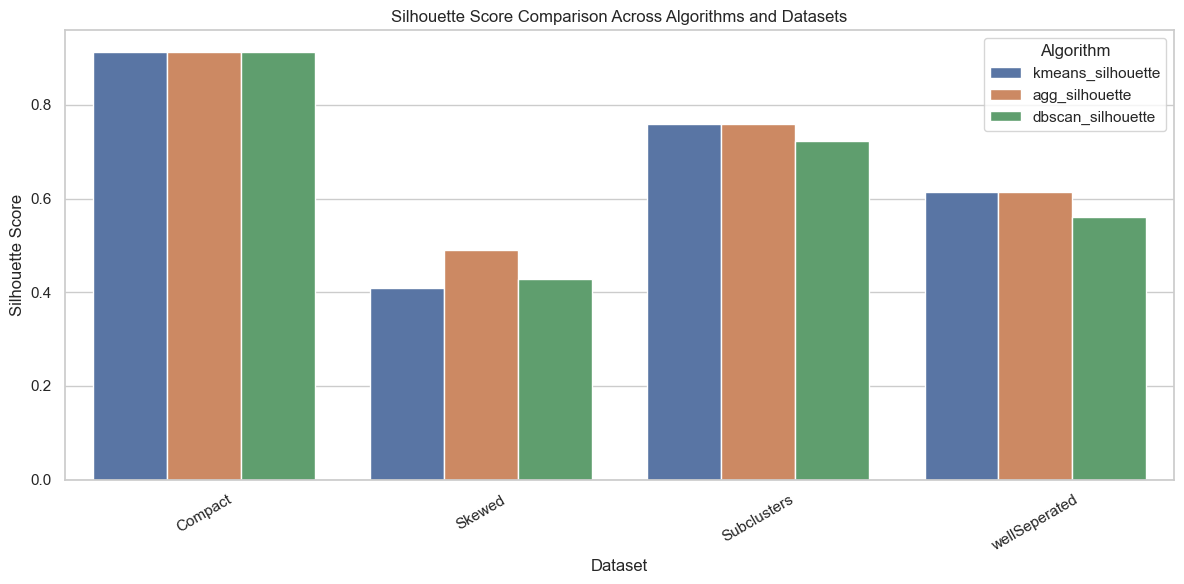

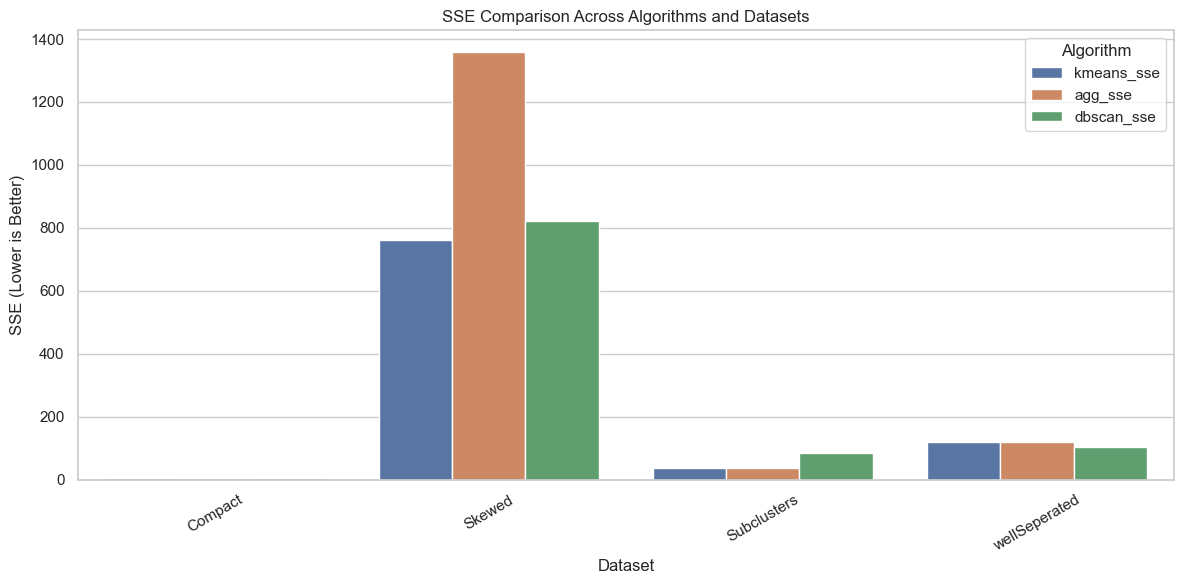

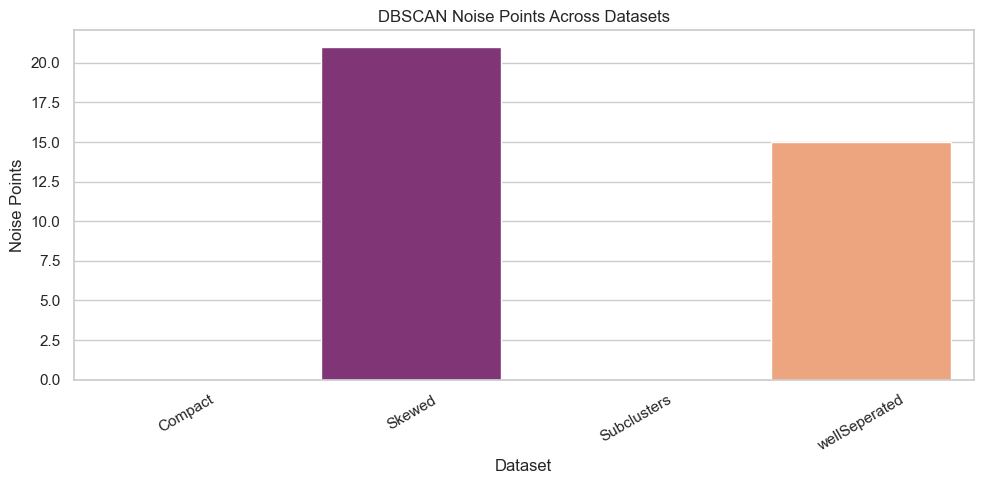

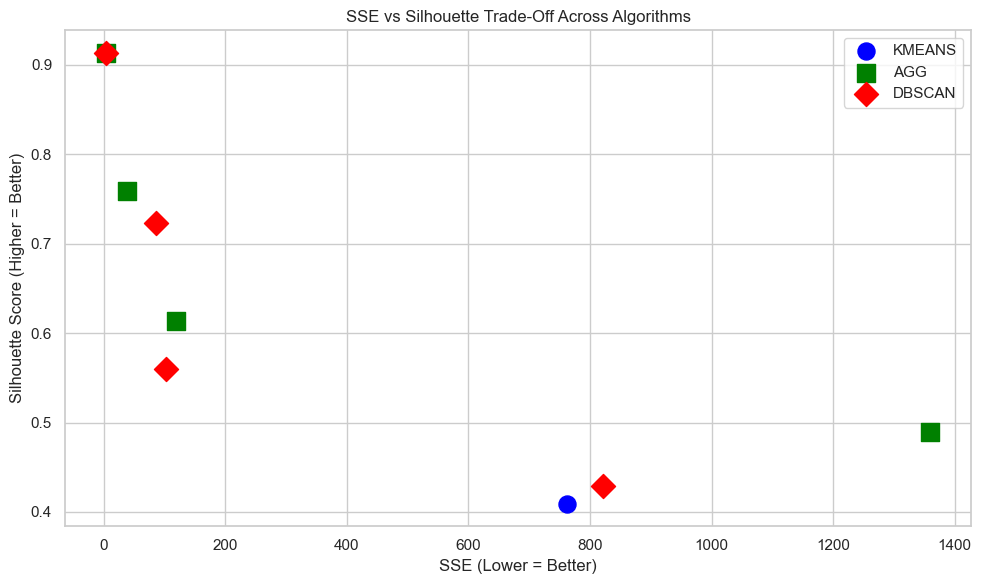

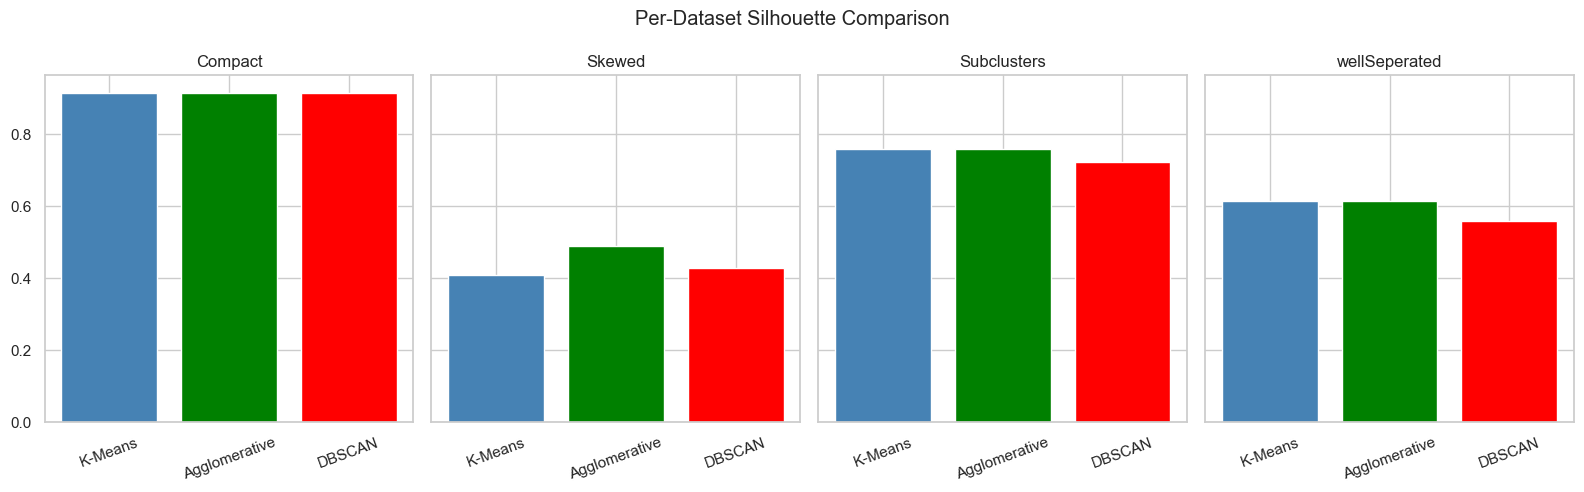

All comparison plots generated successfully!


In [20]:
# ---------------------------------------------------------------------
# 1. Silhouette Score Comparison (Bar Chart)
# ---------------------------------------------------------------------
plt.figure(figsize=(12, 6))
silhouette_melt = results_df.melt(
    id_vars="dataset",
    value_vars=["kmeans_silhouette", "agg_silhouette", "dbscan_silhouette"],
    var_name="algorithm", value_name="silhouette"
)
sns.barplot(data=silhouette_melt, x="dataset", y="silhouette", hue="algorithm")
plt.title("Silhouette Score Comparison Across Algorithms and Datasets")
plt.xlabel("Dataset")
plt.ylabel("Silhouette Score")
plt.xticks(rotation=30)
plt.legend(title="Algorithm")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# 2. SSE Comparison (Bar Chart)
# ---------------------------------------------------------------------
plt.figure(figsize=(12, 6))
sse_melt = results_df.melt(
    id_vars="dataset",
    value_vars=["kmeans_sse", "agg_sse", "dbscan_sse"],
    var_name="algorithm", value_name="sse"
)
sns.barplot(data=sse_melt, x="dataset", y="sse", hue="algorithm")
plt.title("SSE Comparison Across Algorithms and Datasets")
plt.xlabel("Dataset")
plt.ylabel("SSE (Lower is Better)")
plt.xticks(rotation=30)
plt.legend(title="Algorithm")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# 3. DBSCAN Noise Point Comparison
# ---------------------------------------------------------------------
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="dataset", y="dbscan_noise_count", palette="magma")
plt.title("DBSCAN Noise Points Across Datasets")
plt.xlabel("Dataset")
plt.ylabel("Noise Points")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# 4. Silhouette vs SSE (Scatter Plot)
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

algo_map = {
    "kmeans": ("o", "blue"),
    "agg": ("s", "green"),
    "dbscan": ("D", "red")
}

for algo, (marker, color) in algo_map.items():
    ax.scatter(
        results_df[f"{algo}_sse"],
        results_df[f"{algo}_silhouette"],
        s=150, marker=marker, c=color, label=algo.upper()
    )

ax.set_xlabel("SSE (Lower = Better)")
ax.set_ylabel("Silhouette Score (Higher = Better)")
ax.set_title("SSE vs Silhouette Trade-Off Across Algorithms")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# 5. Per-Dataset Silhouette Mini-Bar Charts
# ---------------------------------------------------------------------
algos = ["kmeans_silhouette", "agg_silhouette", "dbscan_silhouette"]
labels = ["K-Means", "Agglomerative", "DBSCAN"]

fig, axes = plt.subplots(1, len(results_df), figsize=(16, 5), sharey=True)

for ax, (_, row) in zip(axes, results_df.iterrows()):
    ax.bar(labels, [row[a] for a in algos], color=["steelblue", "green", "red"])
    ax.set_title(row["dataset"])
    ax.set_ylim(0, max(results_df[algos].max()) + 0.05)
    ax.set_xticklabels(labels, rotation=20)

fig.suptitle("Per-Dataset Silhouette Comparison")
plt.tight_layout()
plt.show()

# =====================================================================
print("All comparison plots generated successfully!")
# =====================================================================
